# Step 1: Import libraries


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


ModuleNotFoundError: No module named 'numpy'

# Sklearn & XGBoost

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score


# Step 2: Load dataset

In [ ]:
df = pd.read_csv('/content/insurance.csv')


# Step 3: Encode categorical columns

In [ ]:
df.replace({
    'sex': {'male': 0, 'female': 1},
    'smoker': {'yes': 0, 'no': 1},
    'region': {'southeast': 0, 'southwest': 1, 'northeast': 2, 'northwest': 3}
}, inplace=True)

/tmp/ipython-input-8-3516543564.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({


# Step 4: Split into features and target

In [ ]:
X = df.drop(columns='charges', axis=1)
Y = df['charges']


# Step 5: Train-test split

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)


# Confirm dimensions


In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1070, 6)
X_test shape: (268, 6)


# Step 6: Train and Compare Models


# Dictionary to store R² scores

In [ ]:
model_scores = {}

# 1. Linear Regression

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, Y_train)
model_scores['Linear Regression'] = {
    "Train R²": r2_score(Y_train, lr_model.predict(X_train)),
    "Test R²": r2_score(Y_test, lr_model.predict(X_test))
}

# 2. Random Forest Regressor


In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, Y_train)
model_scores['Random Forest'] = {
    "Train R²": r2_score(Y_train, rf_model.predict(X_train)),
    "Test R²": r2_score(Y_test, rf_model.predict(X_test))
}

# 3. Ridge Regression


In [ ]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, Y_train)
model_scores['Ridge Regression'] = {
    "Train R²": r2_score(Y_train, ridge_model.predict(X_train)),
    "Test R²": r2_score(Y_test, ridge_model.predict(X_test))
}


# 4. XGBoost Regressor

In [ ]:
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, Y_train)
model_scores['XGBoost'] = {
    "Train R²": r2_score(Y_train, xgb_model.predict(X_train)),
    "Test R²": r2_score(Y_test, xgb_model.predict(X_test))
}

# Step 7: Display Results

In [ ]:
print("\n📊 Model Comparison:")
for model_name, scores in model_scores.items():
    print(f"{model_name}: Train R² = {scores['Train R²']:.4f}, Test R² = {scores['Test R²']:.4f}")



📊 Model Comparison:
Linear Regression: Train R² = 0.7515, Test R² = 0.7447
Random Forest: Train R² = 0.9773, Test R² = 0.8379
Ridge Regression: Train R² = 0.7515, Test R² = 0.7448
XGBoost: Train R² = 0.9634, Test R² = 0.8451


# Save best model (XGBoost here)

In [ ]:
import pickle

# Save best model (XGBoost here)
with open('xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

print("✅ Model saved as xgb_model.pkl")

✅ Model saved as xgb_model.pkl


In [ ]:
pip install shap


In [ ]:
import shap

# Step 1: Initialize SHAP Explainer with your XGBoost model

In [ ]:
explainer = shap.Explainer(xgb_model, X_test)

# Step 2: Calculate SHAP values

In [ ]:
shap_values = explainer(X_test)

# Step 3: Summary Plot (Beeswarm)


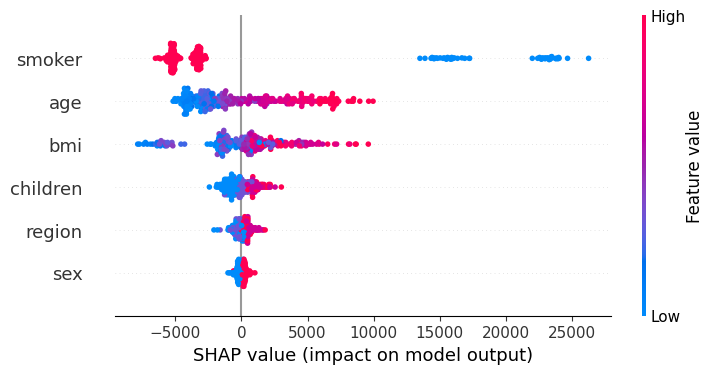

In [ ]:
shap.plots.beeswarm(shap_values)


Step 4.3 (Optional): Bar Plot of Global Feature Importance


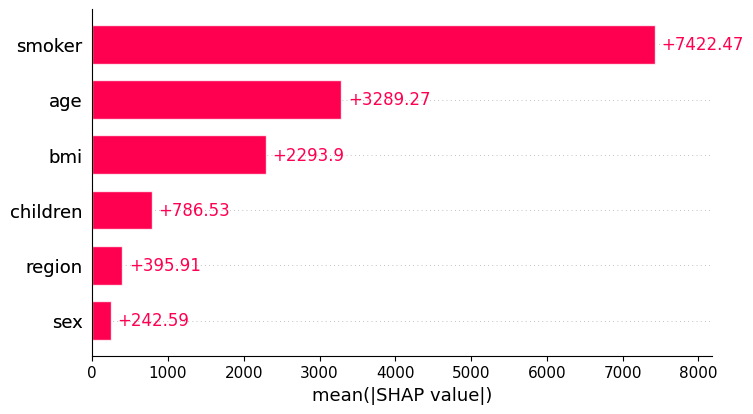

In [ ]:
shap.plots.bar(shap_values)


Step 5.1: Import GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor


 Step 5.2: Define the parameter grid

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1]
}


Step 5.3: Initialize the model and GridSearchCV


In [ ]:
xgb = XGBRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='r2'
)


Step 5.4: Fit on training data (⚠️ takes 2–5 mins)

In [ ]:
grid_search.fit(X_train, Y_train)

print("✅ Best Parameters Found:", grid_search.best_params_)


Fitting 5 folds for each of 36 candidates, totalling 180 fits
✅ Best Parameters Found: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


Step 5.5: Evaluate the tuned model


In [ ]:
best_xgb = grid_search.best_estimator_

# Predict


In [ ]:
Y_train_pred = best_xgb.predict(X_train)
Y_test_pred = best_xgb.predict(X_test)


# Evaluate

In [ ]:
train_r2 = r2_score(Y_train, Y_train_pred)
test_r2 = r2_score(Y_test, Y_test_pred)


In [ ]:
print("📊 Tuned XGBoost Results:")
print(f"Train R²: {train_r2:.4f}")
print(f"Test R²:  {test_r2:.4f}")

📊 Tuned XGBoost Results:
Train R²: 0.8997
Test R²:  0.8668


 Step 5.6: Save the Tuned Model

In [ ]:
import pickle
with open("best_xgb_model.pkl", "wb") as f:
    pickle.dump(best_xgb, f)
print("✅ Tuned model saved as best_xgb_model.pkl")

✅ Tuned model saved as best_xgb_model.pkl


In [ ]:
from google.colab import files
files.download("best_xgb_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>